# YOLOv11 Fine-Tuning Notebook
## Real-time Student Behavior Detection (LGU Dataset)

This notebook fine-tunes our previously trained Kaggle model on the uploaded LGU student engagement dataset.

## 1. Runtime Check and Dependencies
Confirm the Kaggle runtime, Python version, and required packages before starting the fine-tuning run.

In [1]:
import os
import sys, platform

print('Python:', sys.version)
print('Executable:', sys.executable)
print('Platform:', platform.platform())
print('Kaggle env:', os.environ.get('KAGGLE_KERNEL_RUN_TYPE') is not None)

%pip install -q ultralytics opencv-python pyyaml matplotlib pillow gdown

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Executable: /usr/bin/python3
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Kaggle env: True
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## 2. Core Paths & Hardware Check
Set the Kaggle input and working directories, point to the uploaded dataset and base model, and confirm the available hardware.

#### Imports

In [2]:
from pathlib import Path
import json
import yaml
import shutil
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#### Paths

In [3]:
KAGGLE_INPUT_ROOT = Path('/kaggle/input')
KAGGLE_WORKING_ROOT = Path('/kaggle/working')

DATASET_ROOT = KAGGLE_INPUT_ROOT /'datasets'/ 'mustafaxgm'/ 'lgu-student-engagement'/ 'my-custom-dataset' 
BASE_MODEL_WEIGHTS = KAGGLE_INPUT_ROOT / 'datasets'/ 'mustafaxgm'/'fyp-base-model' / 'best.pt'

RUNS_ROOT = KAGGLE_WORKING_ROOT / 'fyp_finetune_runs'
RUNS_ROOT.mkdir(parents=True, exist_ok=True)
RUN_DIR = RUNS_ROOT / 'lgu_classroom_finetune'
BEST_WEIGHTS_NEW = RUN_DIR / 'weights' / 'best.pt'

device = '0' if torch.cuda.is_available() else 'cpu'

print(f'Runs root: {RUNS_ROOT}')
print(f'PyTorch version: {torch.__version__}')
print(f'torch.cuda.is_available(): {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device name: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: GPU is not active. Kaggle CPU training will be slow.')
print(f'Training device setting: {device}')

Runs root: /kaggle/working/fyp_finetune_runs
PyTorch version: 2.10.0+cu128
torch.cuda.is_available(): True
Device name: Tesla T4
Training device setting: 0


## 3. Validate and Fix data.yaml
Rewrite the read-only Kaggle dataset YAML into the working directory so all dataset paths resolve correctly during training.

In [4]:
DATA_YAML_ORIGINAL = DATASET_ROOT / 'data.yaml'

if not DATA_YAML_ORIGINAL.exists():
    raise FileNotFoundError(f'Missing file: {DATA_YAML_ORIGINAL}')

with open(DATA_YAML_ORIGINAL, 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)

if not isinstance(data_cfg, dict):
    raise ValueError('data.yaml is not a valid mapping/dictionary.')

resolved_root = str(DATASET_ROOT.resolve())
data_cfg['path'] = resolved_root
data_cfg['train'] = 'train/images'
data_cfg['val'] = 'valid/images'
data_cfg['test'] = 'test/images'

RUNTIME_DATA_YAML = KAGGLE_WORKING_ROOT / 'data.runtime.yaml'
with open(RUNTIME_DATA_YAML, 'w', encoding='utf-8') as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

DATA_YAML = RUNTIME_DATA_YAML

print(f'Using runtime data.yaml: {DATA_YAML}')
print(json.dumps({
    'path': data_cfg.get('path'),
    'train': data_cfg.get('train'),
    'val': data_cfg.get('val'),
    'test': data_cfg.get('test'),
    'nc': data_cfg.get('nc'),
    'names': data_cfg.get('names')
}, indent=2))

Using runtime data.yaml: /kaggle/working/data.runtime.yaml
{
  "path": "/kaggle/input/datasets/mustafaxgm/lgu-student-engagement/my-custom-dataset",
  "train": "train/images",
  "val": "valid/images",
  "test": "test/images",
  "nc": 8,
  "names": [
    "handrise",
    "look_forward",
    "read",
    "sleep",
    "stand",
    "turn_head",
    "using_device",
    "write"
  ]
}


## 4. Validate Dataset Structure
Check the expected train, valid, and test image and label folders before training starts.

In [5]:
expected_dirs = [
    DATASET_ROOT / 'train' / 'images',
    DATASET_ROOT / 'train' / 'labels',
    DATASET_ROOT / 'valid' / 'images',
    DATASET_ROOT / 'valid' / 'labels',
    DATASET_ROOT / 'test' / 'images',
    DATASET_ROOT / 'test' / 'labels',
]

print('Dataset directory check:')
all_ok = True
for p in expected_dirs:
    ok = p.exists()
    print(f"{'OK ' if ok else 'MISS'} - {p}")
    all_ok = all_ok and ok

if not all_ok:
    raise FileNotFoundError('One or more required dataset folders are missing. Fix dataset structure first.')

expected_names = ['handrise', 'look_forward', 'read', 'sleep', 'stand', 'turn_head', 'using_device', 'write']
names = list(data_cfg.get('names', []))
nc = int(data_cfg.get('nc', -1))

if nc != len(names):
    raise ValueError(f"nc ({nc}) does not match len(names) ({len(names)})")

if names != expected_names:
    print('Warning: class names differ from expected master labels.')
    print('Expected:', expected_names)
    print('Found   :', names)
else:
    print('Class labels match expected master labels.')

print('Dataset validation complete.')

Dataset directory check:
OK  - /kaggle/input/datasets/mustafaxgm/lgu-student-engagement/my-custom-dataset/train/images
OK  - /kaggle/input/datasets/mustafaxgm/lgu-student-engagement/my-custom-dataset/train/labels
OK  - /kaggle/input/datasets/mustafaxgm/lgu-student-engagement/my-custom-dataset/valid/images
OK  - /kaggle/input/datasets/mustafaxgm/lgu-student-engagement/my-custom-dataset/valid/labels
OK  - /kaggle/input/datasets/mustafaxgm/lgu-student-engagement/my-custom-dataset/test/images
OK  - /kaggle/input/datasets/mustafaxgm/lgu-student-engagement/my-custom-dataset/test/labels
Class labels match expected master labels.
Dataset validation complete.


## 5. Fine-Tune YOLO on LGU Dataset
Load the custom base model and run fine-tuning with reduced learning rates and early stopping.

In [6]:
if not BASE_MODEL_WEIGHTS.exists():
    raise FileNotFoundError(f'Cannot find base model at {BASE_MODEL_WEIGHTS}. Make sure you uploaded it correctly to the Input folder!')

print(f'Loading base model: {BASE_MODEL_WEIGHTS}')
model = YOLO(str(BASE_MODEL_WEIGHTS))

train_config = {
    'data': str(DATA_YAML),
    'epochs': 50,
    'imgsz': 640,
    'batch': 16 if device != 'cpu' else 8,
    'device': device,
    'project': str(RUNS_ROOT),
    'name': 'lgu_classroom_finetune',
    'verbose': True,
    'save': True,
    'workers': 4,
    'patience': 15,
    'lr0': 0.001,
    'lrf': 0.0001,
    'warmup_epochs': 0.0,
    'optimizer': 'auto',
    'cos_lr': True,
    'plots': True,
    'seed': 42,
    'save_period': 1,
}

print('Starting Fine-Tuning with config:')
for k, v in train_config.items():
    print(f'  {k}: {v}')

train_results = model.train(**train_config)
print('Fine-Tuning complete.')
print(f'Expected NEW best weights at: {BEST_WEIGHTS_NEW}')

Loading base model: /kaggle/input/datasets/mustafaxgm/fyp-base-model/best.pt
Starting Fine-Tuning with config:
  data: /kaggle/working/data.runtime.yaml
  epochs: 50
  imgsz: 640
  batch: 16
  device: 0
  project: /kaggle/working/fyp_finetune_runs
  name: lgu_classroom_finetune
  verbose: True
  save: True
  workers: 4
  patience: 15
  lr0: 0.001
  lrf: 0.0001
  warmup_epochs: 0.0
  optimizer: auto
  cos_lr: True
  plots: True
  seed: 42
  save_period: 1
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.runtime.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, 

## 6. Evaluate the Fine-Tuned Model
Run validation on the blind test split and print the evaluation metrics and artifact paths.

In [7]:
if not BEST_WEIGHTS_NEW.exists():
    raise FileNotFoundError('Training failed to output weights.')

test_model = YOLO(str(BEST_WEIGHTS_NEW))

test_config = {
    'data': str(DATA_YAML),
    'split': 'test',
    'imgsz': 640,
    'batch': 16,
    'device': device,
    'project': str(RUNS_ROOT),
    'name': 'lgu_classroom_finetune_test',
    'verbose': True,
    'plots': True,
}

print('Running blind test set evaluation...')
test_results = test_model.val(**test_config)
print('Testing complete.')

results_dir = Path(getattr(test_results, 'save_dir', RUNS_ROOT / 'lgu_classroom_finetune_test'))
print(f'Test artifacts saved to: {results_dir}')

if hasattr(test_results, 'results_dict'):
    print('Metrics:')
    print(json.dumps(test_results.results_dict, indent=2, default=str))

confusion_matrix_path = results_dir / 'confusion_matrix.png'
results_png_path = results_dir / 'results.png'
print(f'Confusion matrix exists: {confusion_matrix_path.exists()}')
print(f'Results plot exists: {results_png_path.exists()}')

Running blind test set evaluation...
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,036,200 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 12.3±2.6 MB/s, size: 29.9 KB)
val: Scanning /kaggle/input/datasets/mustafaxgm/lgu-student-engagement/my-custom-dataset/test/labels... 74 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 74/74 397.0it/s 0.2s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/mustafaxgm/lgu-student-engagement/my-custom-dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.4it/s 3.6s
                   all         74        710      0.713      0.553      0.585       0.31
              handrise          3          3          1          0          0          0
          look_forward         69        349       0.67        0.7      0.705      0.3

Artifacts:
OK  - /kaggle/working/fyp_finetune_runs/lgu_classroom_finetune/results.png
OK  - /kaggle/working/fyp_finetune_runs/lgu_classroom_finetune/confusion_matrix.png
MISS - /kaggle/working/fyp_finetune_runs/lgu_classroom_finetune/PR_curve.png
MISS - /kaggle/working/fyp_finetune_runs/lgu_classroom_finetune/F1_curve.png
OK  - /kaggle/working/fyp_finetune_runs/lgu_classroom_finetune/val_batch0_pred.jpg


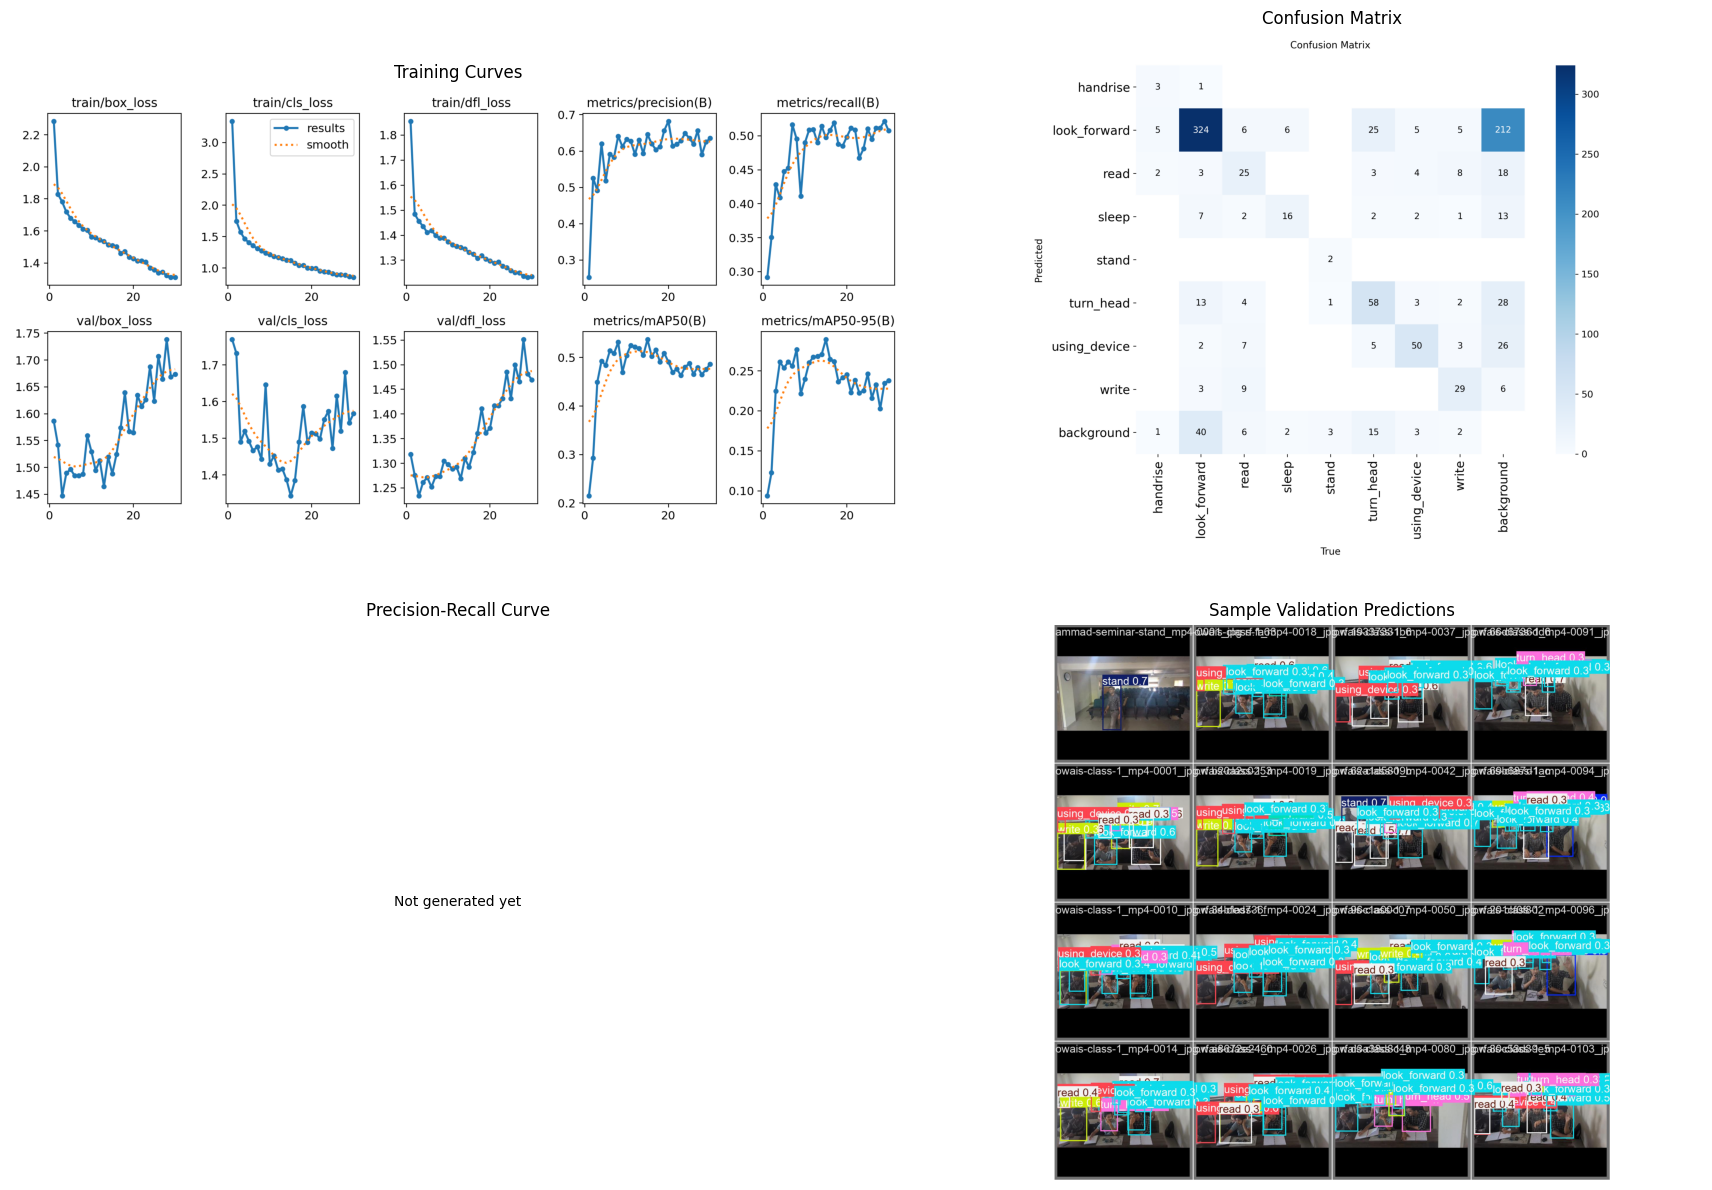

In [8]:
results_png = RUN_DIR / 'results.png'
cm_png = RUN_DIR / 'confusion_matrix.png'
pr_curve_png = RUN_DIR / 'PR_curve.png'
f1_curve_png = RUN_DIR / 'F1_curve.png'
val_batch_png = RUN_DIR / 'val_batch0_pred.jpg'

print('Artifacts:')
for p in [results_png, cm_png, pr_curve_png, f1_curve_png, val_batch_png]:
    print(f"{'OK ' if p.exists() else 'MISS'} - {p}")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
images = [results_png, cm_png, pr_curve_png, val_batch_png]
titles = ['Training Curves', 'Confusion Matrix', 'Precision-Recall Curve', 'Sample Validation Predictions']

for ax, img_path, title in zip(axes.flat, images, titles):
    ax.set_title(title)
    ax.axis('off')
    if img_path.exists():
        img = Image.open(img_path)
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, 'Not generated yet', ha='center', va='center')

plt.tight_layout()
plt.show()

## 7. Visualize Training Results
Display the saved training curves, confusion matrix, precision-recall curve, and sample validation predictions.

Training metrics summary:
 epoch    time  train/box_loss  train/cls_loss  train/dfl_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss   lr/pg0   lr/pg1   lr/pg2
    26 1103.90         1.33859         0.89265         1.25073               0.61956            0.49507           0.46600              0.21602       1.70709       1.61603       1.50006 0.000417 0.000417 0.000417
    27 1145.66         1.34263         0.89441         1.25059               0.65639            0.51156           0.47978              0.23277       1.66458       1.51980       1.46579 0.000390 0.000390 0.000390
    28 1187.67         1.32195         0.88772         1.23601               0.58980            0.51175           0.46484              0.20262       1.73845       1.67995       1.55127 0.000364 0.000364 0.000364
    29 1229.44         1.31003         0.86755         1.23169               0.62517            0.52165           0.47587     

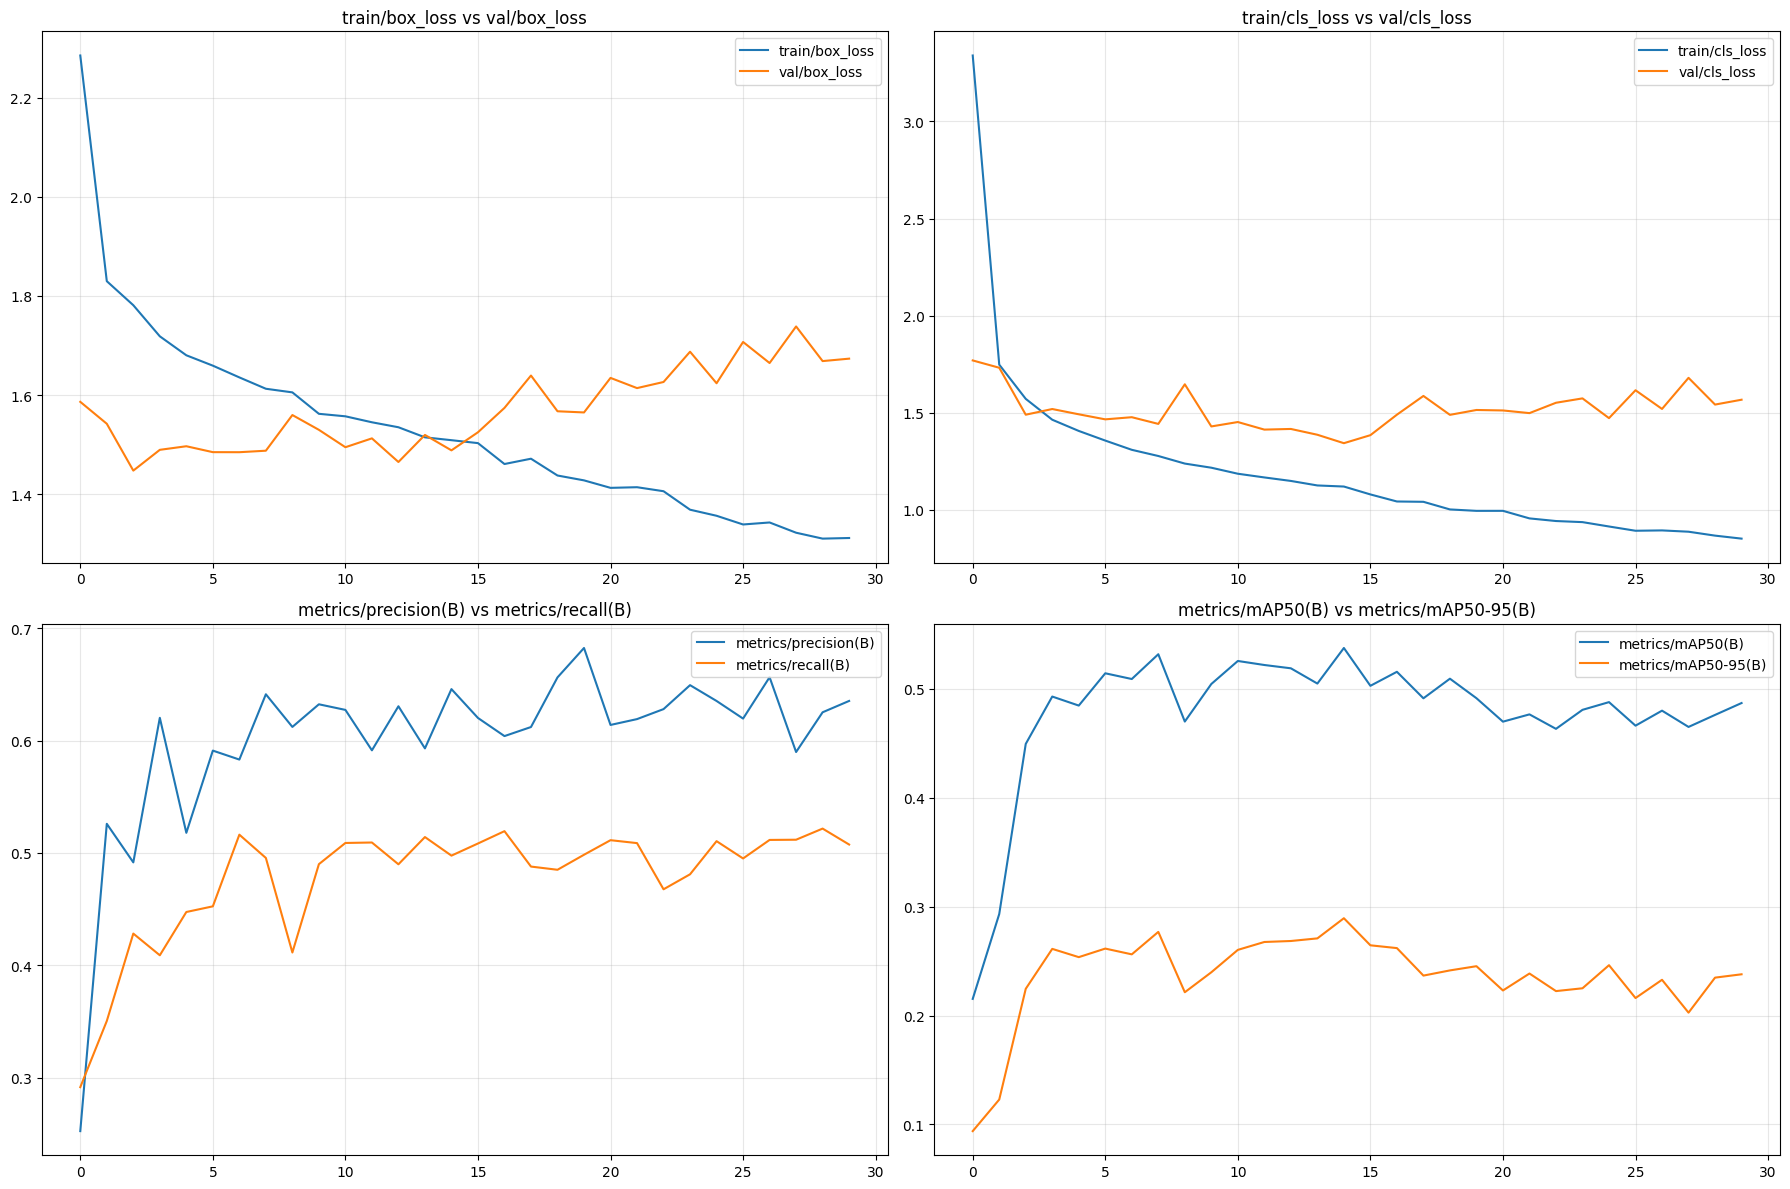

In [9]:
import pandas as pd

results_csv = RUN_DIR / 'results.csv'
if not results_csv.exists():
    print(f'Missing results.csv: {results_csv}')
else:
    df = pd.read_csv(results_csv)
    print('Training metrics summary:')
    print(df.tail(5).to_string(index=False))

    metric_candidates = [
        ('train/box_loss', 'val/box_loss'),
        ('train/cls_loss', 'val/cls_loss'),
        ('metrics/precision(B)', 'metrics/recall(B)'),
        ('metrics/mAP50(B)', 'metrics/mAP50-95(B)'),
    ]

    available_columns = set(df.columns)
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()

    for ax, pair in zip(axes, metric_candidates):
        left, right = pair
        ax.set_title(f'{left} vs {right}')
        plotted = False
        if left in available_columns:
            ax.plot(df[left], label=left)
            plotted = True
        if right in available_columns:
            ax.plot(df[right], label=right)
            plotted = True
        if plotted:
            ax.legend()
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'Metric columns not found', ha='center', va='center')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

## 8. Inspect Training Metrics Table
Summarize the final `results.csv` rows and plot the training metrics that were logged during fine-tuning.

## 9. Export Kaggle Artifacts
Zip the fine-tuned run directory so the trained weights and plots can be downloaded from Kaggle.

In [10]:
archive_base = KAGGLE_WORKING_ROOT / 'lgu_finetuned_artifacts'
archive_path = shutil.make_archive(str(archive_base), 'zip', root_dir=str(RUN_DIR)) if RUN_DIR.exists() else None

if archive_path:
    print(f'Created final artifact zip: {archive_path}')
    print('Download this zip file from the Kaggle working directory. Your new weights are inside!')
else:
    print(f'Run directory not found: {RUN_DIR}')

Created final artifact zip: /kaggle/working/lgu_finetuned_artifacts.zip
Download this zip file from the Kaggle working directory. Your new weights are inside!
